<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ вакансий из HeadHunter
   

In [695]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [696]:
# вставьте сюда параметры подключения из юнита 1. Работа с базой данных из Python
connection = psycopg2.connect(
   dbname='dbname',
   user='user',
   host='host',
   password='password',
   port=port
)

# Юнит 3. Предварительный анализ данных

1. Напишите запрос, который посчитает количество вакансий в нашей базе (вакансии находятся в таблице vacancies). 

In [697]:
# текст запроса
query_3_1 = f'''
                select count(*) as cnt from vacancies;
            '''

In [698]:
# результат запроса (датафрейм)
df_vacancies = pd.read_sql_query(query_3_1, connection)
display(df_vacancies['cnt'][0]);

np.int64(49197)

2. Напишите запрос, который посчитает количество работодателей (таблица employers). 

In [699]:
# текст запроса
query_3_2 = f'''
                select count(*) as cnt from employers;
            '''

In [700]:
# результат запроса (датафрейм)
df_epmloyers = pd.read_sql_query(query_3_2, connection)
display(df_epmloyers['cnt'][0]);

np.int64(23501)

3. Посчитате с помощью запроса количество регионов (таблица areas).

In [701]:
# текст запроса
query_3_3 = f'''
                select count(*) as cnt from areas;
            '''

In [702]:
# результат запроса (датафрейм)
df_areas = pd.read_sql_query(query_3_3, connection)
display(df_areas['cnt'][0]);

np.int64(1362)

4. Посчитате с помощью запроса количество сфер деятельности в базе (таблица industries).

In [703]:
# текст запроса
query_3_4 = f'''
                select count(*) as cnt from industries;
            '''

In [704]:
# результат запроса (датафрейм)
df_industries = pd.read_sql_query(query_3_4, connection)
display(df_industries['cnt'][0]);

np.int64(294)

***

#### Выводы по Юниту 3:
- Общее количество вакансий в базе составило 49197
- На одного работодателя (23501) в базе в среднем приходится две вакансии
- В базе представлена выборка по 1362 регионам и 294 сферам деятельности

# Юнит 4. Детальный анализ вакансий

1. Напишите запрос, который позволит узнать, сколько (cnt) вакансий в каждом регионе (area).
Отсортируйте по количеству вакансий в порядке убывания.

In [705]:
# текст запроса
query_4_1 = f'''
                select areas.name, count(vacancies.id) as cnt 
                from vacancies
                left join areas on vacancies.area_id = areas.id 
                group by areas.name
                order by cnt desc
                limit 10;
            '''

In [706]:
# результат запроса (датафрейм)
df_vac_areas = pd.read_sql_query(query_4_1, connection)
display(df_vac_areas);

,name,cnt
0,Москва,5333
1,Санкт-Петербург,2851
2,Минск,2112
3,Новосибирск,2006
4,Алматы,1892
5,Екатеринбург,1698
6,Нижний Новгород,1670
7,Казань,1415
8,Краснодар,1301
9,Самара,1144


2. Напишите запрос, чтобы определить у какого количества вакансий заполнено хотя бы одно из двух полей с зарплатой.

In [707]:
# текст запроса
query_4_2 = f'''
                select count(*) as cnt 
                from vacancies
                where salary_from is not null or salary_to is not null;
            '''

In [708]:
# результат запроса (датафрейм)
df_vac_salary = pd.read_sql_query(query_4_2, connection)
display(df_vac_salary['cnt'][0]);

np.int64(24073)

3. Найдите средние значения для нижней и верхней границы зарплатной вилки. Округлите значения до целого.

In [709]:
# текст запроса
query_4_3 = f'''
                select avg(salary_from) as avg_salary_from, avg(salary_to) as avg_salary_to 
                from vacancies;
            '''

In [710]:
# результат запроса (датафрейм)
df_mean_vac_salary = pd.read_sql_query(query_4_3, connection)
display(df_mean_vac_salary);

,avg_salary_from,avg_salary_to
0,71064.657901,110536.741923


4. Напишите запрос, который выведет количество вакансий для каждого сочетания типа рабочего графика (schedule) и типа трудоустройства (employment), используемого в вакансиях. Результат отсортируйте по убыванию количества.


In [711]:
# текст запроса
query_4_4 = f'''
                select schedule,employment,count(*) as cnt  
                from vacancies
                group by schedule,employment
                order by cnt desc
                ;
            '''

In [712]:
# результат запроса (датафрейм)
df_count_vac_sched_emp = pd.read_sql_query(query_4_4, connection)
display(df_count_vac_sched_emp);

,schedule,employment,cnt
0,Полный день,Полная занятость,35367
1,Удаленная работа,Полная занятость,7802
2,Гибкий график,Полная занятость,1593
3,Удаленная работа,Частичная занятость,1312
4,Сменный график,Полная занятость,940
5,Полный день,Стажировка,569
6,Вахтовый метод,Полная занятость,367
7,Полный день,Частичная занятость,347
8,Гибкий график,Частичная занятость,312
9,Полный день,Проектная работа,141


5. Напишите запрос, выводящий значения поля Требуемый опыт работы (experience) в порядке возрастания количества вакансий, в которых указан данный вариант опыта. 

In [713]:
# текст запроса
query_4_5 = f'''
                select experience,count(*) as cnt  
                from vacancies
                group by experience
                order by cnt asc
                ;
            '''

In [714]:
# результат запроса (датафрейм)
df_count_vac_exp = pd.read_sql_query(query_4_5, connection)
display(df_count_vac_exp);

,experience,cnt
0,Более 6 лет,1337
1,Нет опыта,7197
2,От 3 до 6 лет,14511
3,От 1 года до 3 лет,26152


***

#### Выводы по детальному анализу вакансий:
- Наибольшее количество вакансий в базе размещено в городах-миллионниках: Москва, Санкт-Петербург, Минск, Новосибирск, Алматы.
  При этом Москва опережает Санкт-Петербург по вакансиям почти в 2 раза. 
- В почти половине вакансий (24073) не указана одна из границ зарплаты (нижняя или верхняя).
- Средние значения границ для зарплаты (тыс. руб.) составляют: 71 (нижняя) и 111 (верхняя).
- Самое популярное сочетание рабочего графика и типа трудоустройства: полный рабочий день с полной занятостью.
- В вакансиях наиболее часто требуется опыт от 1 до 3 лет.
    
##### Комплексный вывод (комбинация признаков):
Наибольшее количество вакансий представлены в Москве, предполагают полный рабочий день с полной занятостью, требуют опыт работы от 1 до 3 лет.

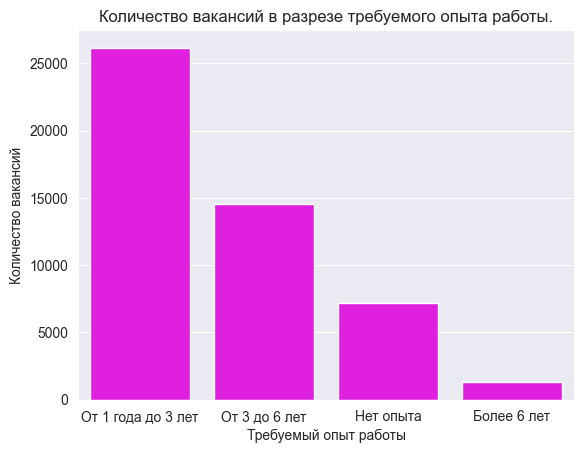

In [715]:
# Построение гистограммы
# преобразование данных
df_count_vac_exp = df_count_vac_exp.sort_values('cnt',ascending=False)
# построение графика
chart_4_1 = sns.barplot(df_count_vac_exp, x='experience', y='cnt', color='magenta')
chart_4_1.set_title('Количество вакансий в разрезе требуемого опыта работы.')
chart_4_1.set(xlabel="Требуемый опыт работы", ylabel="Количество вакансий");

# Юнит 5. Анализ работодателей

1. Напишите запрос, который позволит узнать, какие работодатели находятся на первом и пятом месте по количеству вакансий.

In [716]:
# текст запроса
query_5_1 = f'''
                select employers.name, count(vacancies.id) as cnt 
                from vacancies
                left join employers on employers.id = vacancies.employer_id 
                group by employers.name
                order by cnt desc
                limit 5;
                ;
            '''

In [717]:
# результат запроса (датафрейм)
df_count_vac_emp = pd.read_sql_query(query_5_1, connection)
display(df_count_vac_emp);

,name,cnt
0,Яндекс,1933
1,Ростелеком,491
2,Тинькофф,444
3,СБЕР,428
4,Газпром нефть,331


2. Напишите запрос, который для каждого региона выведет количество работодателей и вакансий в нём.
Среди регионов, в которых нет вакансий, найдите тот, в котором наибольшее количество работодателей.


In [718]:
# текст запроса
query_5_2 = f'''
                select areas_name,emp_cnt,vac_cnt
                from (
                    select areas.name areas_name, count(employers.id) as emp_cnt, count(vacancies.id) as vac_cnt  from areas
                    left join employers on employers.area = areas.id
                    left join vacancies on vacancies.area_id = areas.id
                    group by areas.name
                ) table_itog
                where emp_cnt > 0 and vac_cnt = 0
                order by  emp_cnt desc
                limit 1;
            '''

In [719]:
# результат запроса (датафрейм)
df_count_vac_emp_area = pd.read_sql_query(query_5_2, connection)
display(df_count_vac_emp_area['areas_name'][0]);

'Россия'

3. Для каждого работодателя посчитайте количество регионов, в которых он публикует свои вакансии. Отсортируйте результат по убыванию количества.


In [720]:
# текст запроса
query_5_3 = f'''
                select name_emp, count(area_id) as cnt 
                from (
                    select distinct employers.name as name_emp, area_id  from vacancies 
                    left join employers on employers.id = vacancies.employer_id
                ) table_1
                group by name_emp
                order by cnt desc
                ;
            '''

In [721]:
# результат запроса (датафрейм)
df_count_emp_area = pd.read_sql_query(query_5_3, connection)
display(df_count_emp_area);

,name_emp,cnt
0,Яндекс,181
1,Ростелеком,152
2,Спецремонт,116
3,Поляков Денис Иванович,88
4,ООО ЕФИН,71
...,...,...
14761,Интеркросс,1
14762,Русская дымка,1
14763,Автономная некоммерческая организация Московск...,1
14764,Транспортный холдинг города Алматы,1


4. Напишите запрос для подсчёта количества работодателей, у которых не указана сфера деятельности. 

In [722]:
# текст запроса
query_5_4 = f'''
                select count(employers.name) as cnt_emp 
                from employers
                left join employers_industries on employers.id = employers_industries.employer_id
                where employers_industries.employer_id is null
                ;
            '''

In [723]:
# результат запроса (датафрейм)
df_count_emp_ind = pd.read_sql_query(query_5_4, connection)
display(df_count_emp_ind['cnt_emp'][0]);

np.int64(8419)

5. Напишите запрос, чтобы узнать название компании, находящейся на третьем месте в алфавитном списке (по названию) компаний, у которых указано четыре сферы деятельности. 

In [724]:
# текст запроса
query_5_5 = f'''
                select employers.name, count(employers_industries.employer_id) as cnt_ind 
                from employers
                left join employers_industries on employers.id = employers_industries.employer_id
                group by employers.name
                having count(employers_industries.employer_id) = 4
                order by employers.name;
            '''

In [725]:
# результат запроса (датафрейм)
df_count_empname_ind = pd.read_sql_query(query_5_5, connection)
display(df_count_empname_ind['name'][2]);

'2ГИС'

6. С помощью запроса выясните, у какого количества работодателей в качестве сферы деятельности указана Разработка программного обеспечения.


In [726]:
# текст запроса
query_5_6 = f'''
                select count(employers.name) as cnt_emp 
                from employers
                left join employers_industries on employers.id = employers_industries.employer_id
                left join industries on  industries.id = employers_industries.industry_id 
                    and industries.name = 'Разработка программного обеспечения'
                where industries.name is not null
                ;
            '''

In [727]:
# результат запроса (датафрейм)
df_count_emp_ind_soft = pd.read_sql_query(query_5_6, connection)
display(df_count_emp_ind_soft['cnt_emp'][0]);

np.int64(3553)

7. Для компании «Яндекс» выведите список регионов-миллионников, в которых представлены вакансии компании, вместе с количеством вакансий в этих регионах. Также добавьте строку Total с общим количеством вакансий компании. Результат отсортируйте по возрастанию количества.

Список городов-милионников надо взять [отсюда](https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8). 

Если возникнут трудности с этим задание посмотрите материалы модуля  PYTHON-17. Как получать данные из веб-источников и API. 

In [728]:
# код для получения списка городов-миллионников
# Получение данных из Интернет
url = 'https://ru.wikipedia.org/wiki/Города-миллионеры_России'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
response = requests.get(url, headers=headers)
response.encoding = 'utf-8'
# Преобразование данных
tables = pd.read_html(io.StringIO(response.text))
df_town = tables[0]
town_list = list(df_town['Город'])
town_str =  str(town_list).strip('[]')

In [729]:
# текст запроса
query_5_7 = f'''
                select name,cnt_vac from (
                select areas.name, count(vacancies.id) as cnt_vac   from vacancies
                left join employers on employers.id = employer_id
                left join areas on areas.id = area_id
                where employers.name = 'Яндекс' and areas.name in ({town_str})
                group by employers.name,areas.name
                union all
                select 'Total' as name, count(vacancies.id) as cnt_vac   from vacancies
                left join employers on employers.id = employer_id
                left join areas on areas.id = area_id
                where employers.name = 'Яндекс' and areas.name in ({town_str})
                ) table_itog
                order by cnt_vac asc
                ;
            '''

In [730]:
# результат запроса (датафрейм)
df_count_emp_vac = pd.read_sql_query(query_5_7, connection)
display(df_count_emp_vac);

,name,cnt_vac
0,Омск,21
1,Челябинск,22
2,Красноярск,23
3,Волгоград,24
4,Пермь,25
5,Казань,25
6,Ростов-на-Дону,25
7,Уфа,26
8,Самара,26
9,Краснодар,30


***

#### Выводы по анализу работодателей
- Наибольшее количество вакансий в базе у работодателя "Яндекс" (1933).
- Странная ситуация сложилась в регионе "Россия": 410 работодателей и 0 вакансий. Можно предположить, что этот регион в базе является аномалией.
- Наибольшее количество регионов (181) с вакансиями в базе у работодателя "Яндекс".
- Около 36 % работодателей (8419) не указали сферу своей деятельности.
- Лишь 15 % работодателей (3553) указали разработку программного обеспечения в качестве сферы своей деятельности.
- В городах-миллионниках работодатель "Яндекс" разместил 485 вакансий, что составило менее 10 % от общего числа вакансий.

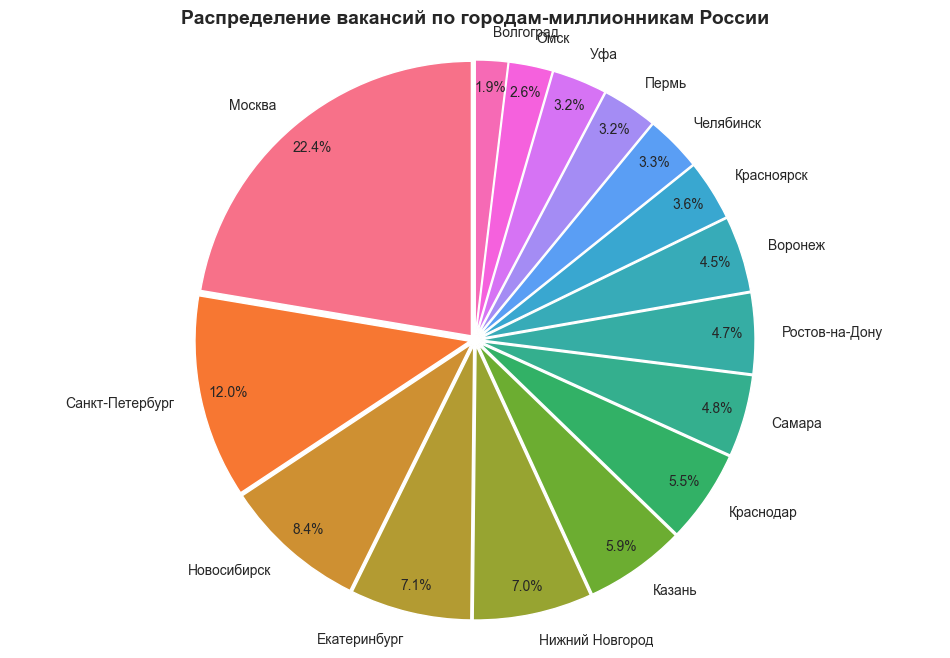

In [731]:
# Визуализация распределения вакансий по городам
# текст запроса для создания круговой диаграммы распределения выкансий по городам
query_conclusions_1 = f'''
                select areas.name, count(vacancies.id) as cnt_vac   from vacancies
                left join employers on employers.id = employer_id
                left join areas on areas.id = area_id
                where areas.name in ({town_str})
                group by areas.name
                ;
            '''

#результат запроса (датафрейм)
df_town_vac = pd.read_sql_query(query_conclusions_1, connection)
df_count_vac_exp = df_town_vac.sort_values('cnt_vac',ascending=False)

# Применяем стиль seaborn
sns.set_style("darkgrid")
sns.set_palette("Set2")  # качественная палитра
colors = sns.color_palette("husl", len(df_count_vac_exp))
plt.figure(figsize=(12, 8))

# Строим круговую диаграмму
plt.pie(
    x=df_count_vac_exp['cnt_vac'],
    labels=df_count_vac_exp['name'],
    autopct='%1.1f%%',
    colors=colors,
    pctdistance=0.9,  # размещение значений
    explode=[0.02] * len(df_count_vac_exp),  # небольшое отделение секторов
    shadow=False,  # тень
    startangle=90  # начальный угол
)

plt.title('Распределение вакансий по городам-миллионникам России', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()


# Юнит 6. Предметный анализ

1. Сколько вакансий имеет отношение к данным?

Считаем, что вакансия имеет отношение к данным, если в её названии содержатся слова 'data' или 'данн'.

*Подсказка: Обратите внимание, что названия вакансий могут быть написаны в любом регистре.* 


In [732]:
# текст запроса
query_6_1 = f'''
                select count(*) as cnt  from vacancies
                where LOWER(name) like '%data%' or LOWER(name) like '%данн%';
            '''

In [733]:
# результат запроса (датафрейм)
df_count_vac_data = pd.read_sql_query(query_6_1, connection)
print(f'К данным имеет отношение: {df_count_vac_data['cnt'][0]} вакансия.');

К данным имеет отношение: 1771 вакансия.


2. Сколько есть подходящих вакансий для начинающего дата-сайентиста? 
Будем считать вакансиями для дата-сайентистов такие, в названии которых есть хотя бы одно из следующих сочетаний:
* 'data scientist'
* 'data science'
* 'исследователь данных'
* 'ML' (здесь не нужно брать вакансии по HTML)
* 'machine learning'
* 'машинн%обучен%'

** В следующих заданиях мы продолжим работать с вакансиями по этому условию.*

Считаем вакансиями для специалистов уровня Junior следующие:
* в названии есть слово 'junior' *или*
* требуемый опыт — Нет опыта *или*
* тип трудоустройства — Стажировка.
 

In [734]:
# текст запроса
query_6_2 = f'''
                select * from (
                select  *  from vacancies
                where    
                        (
                        name ilike '%data scientist%' or 
                        name ilike '%data science%' or
                        name ilike '%исследователь данных%' or
                        (name like '%ML%' and name not ilike '%HTML%') or
                        name ilike '%machine learning%' or
                        name ilike '%машинн%обучен%'
                        ) 
                ) table_itog                        
                where 
                        name ilike '%junior%' or 
                        experience = 'Нет опыта' or
                        employment = 'Стажировка';
            '''

In [735]:
# результат запроса (датафрейм)
df_count_vac_data = pd.read_sql_query(query_6_2, connection)
print(f'Для начинающего дата-сайентиста найдено подходящих вакансий: {df_count_vac_data.shape[0]}');

Для начинающего дата-сайентиста найдено подходящих вакансий: 51


3. Сколько есть вакансий для DS, в которых в качестве ключевого навыка указан SQL или postgres?

** Критерии для отнесения вакансии к DS указаны в предыдущем задании.*

In [736]:
# текст запроса
query_6_3 = f'''
                select * from vacancies
                where    
                        (
                        name ilike '%data scientist%' or 
                        name ilike '%data science%' or
                        name ilike '%исследователь данных%' or
                        ((name ilike '%ML%') and (name not ilike '%HTML%')) or
                        name ilike '%machine learning%' or
                        name ilike '%машинн%обучен%'
                        ) 
                        and (key_skills ilike '%SQL%' or key_skills ilike '%postgres%');
            '''

In [737]:
# результат запроса (датафрейм)
df_count_vac_dt_db = pd.read_sql_query(query_6_3, connection)
print(f'Подходящих вакансий, в которых указан ключевой навык SQL или postgres: {df_count_vac_dt_db.shape[0]}');

Подходящих вакансий, в которых указан ключевой навык SQL или postgres: 229


4. Проверьте, насколько популярен Python в требованиях работодателей к DS.Для этого вычислите количество вакансий, в которых в качестве ключевого навыка указан Python.

** Это можно сделать помощью запроса, аналогичного предыдущему.*

In [738]:
# текст запроса
query_6_4 = f'''
                select * from vacancies
                where    
                        (
                        name ilike '%data scientist%' or 
                        name ilike '%data science%' or
                        name ilike '%исследователь данных%' or
                        ((name ilike '%ML%') and (name not ilike '%HTML%')) or
                        name ilike '%machine learning%' or
                        name ilike '%машинн%обучен%'
                        ) 
                        and key_skills ilike '%Python%';
            '''

In [739]:
# результат запроса (датафрейм)
df_count_vac_dt_py = pd.read_sql_query(query_6_4, connection)
print(f'Подходящих вакансий, в которых указан ключевой навык Python: {df_count_vac_dt_py.shape[0]}');

Подходящих вакансий, в которых указан ключевой навык Python: 357


5. Сколько ключевых навыков в среднем указывают в вакансиях для DS?
Ответ округлите до двух знаков после точки-разделителя.

In [740]:
# текст запроса
query_6_5 = f'''
                select round(avg(length(key_skills)-length(replace(key_skills, CHR(9), ''))+1), 2) as skill_count
                from vacancies
                where 
                (
                    name ilike '%data scientist%' or 
                    name ilike '%data science%' or
                    name ilike '%исследователь данных%' or
                    ((name like '%ML%') and (name not ilike '%HTML%')) or
                    name ilike '%machine learning%' or
                    name ilike '%машинн%обучен%'                
                )  ;
            '''

In [741]:
# результат запроса (датафрейм)
df_count_vac_dt_skill = pd.read_sql_query(query_6_5, connection)
print(f'В среднем для DS указывают ключевых навыков: {df_count_vac_dt_skill['skill_count'][0]}');

В среднем для DS указывают ключевых навыков: 6.41


6. Напишите запрос, позволяющий вычислить, какую зарплату для DS в **среднем** указывают для каждого типа требуемого опыта (уникальное значение из поля *experience*). 

При решении задачи примите во внимание следующее:
1. Рассматриваем только вакансии, у которых заполнено хотя бы одно из двух полей с зарплатой.
2. Если заполнены оба поля с зарплатой, то считаем зарплату по каждой вакансии как сумму двух полей, делённую на 2. Если заполнено только одно из полей, то его и считаем зарплатой по вакансии.
3. Если в расчётах участвует null, в результате он тоже даст null (посмотрите, что возвращает запрос select 1 + null). Чтобы избежать этой ситуацию, мы воспользуемся функцией [coalesce](https://postgrespro.ru/docs/postgresql/9.5/functions-conditional#functions-coalesce-nvl-ifnull), которая заменит null на значение, которое мы передадим. Например, посмотрите, что возвращает запрос `select 1 + coalesce(null, 0)`

Выясните, на какую зарплату в среднем может рассчитывать дата-сайентист с опытом работы от 3 до 6 лет. Результат округлите до целого числа. 

In [749]:
# текст запроса
query_6_6 = f'''
            select experience,
            avg(case 
                when salary_from is null then salary_to
                when salary_to is null then salary_from
                when salary_from is not null and salary_to is not null then (salary_from + salary_to) / 2
                else null
            end ) as salary
            from vacancies
            where 
            (
                name ilike '%data scientist%' or 
                name ilike '%data science%' or
                name ilike '%исследователь данных%' or
                ((name like '%ML%') and (name not ilike '%HTML%')) or
                name ilike '%machine learning%' or
                name ilike '%машинн%обучен%'                
            )   and (salary_from is not null or salary_to is not null)
            group by experience ;
            '''

In [750]:
# результат запроса (датафрейм)
df_count_vac_dt_salary = pd.read_sql_query(query_6_6, connection)
print(f'В среднем дата-сайентист с опытом работы от 3 до 6 лет может рассчитывать на зарплату: {df_count_vac_dt_salary['salary'][2].round()}');
display(df_count_vac_dt_salary)

В среднем дата-сайентист с опытом работы от 3 до 6 лет может рассчитывать на зарплату: 243115.0


,experience,salary
0,Нет опыта,74642.857143
1,От 1 года до 3 лет,139674.750000
2,От 3 до 6 лет,243114.666667


***

##### Для визуализации выводов по предметному анализу построим диаграммы:
- ТОП-10 ключевых навыков для Data Scientist
- Количество вакансий для Data Scientist в зависимости от графика работы 

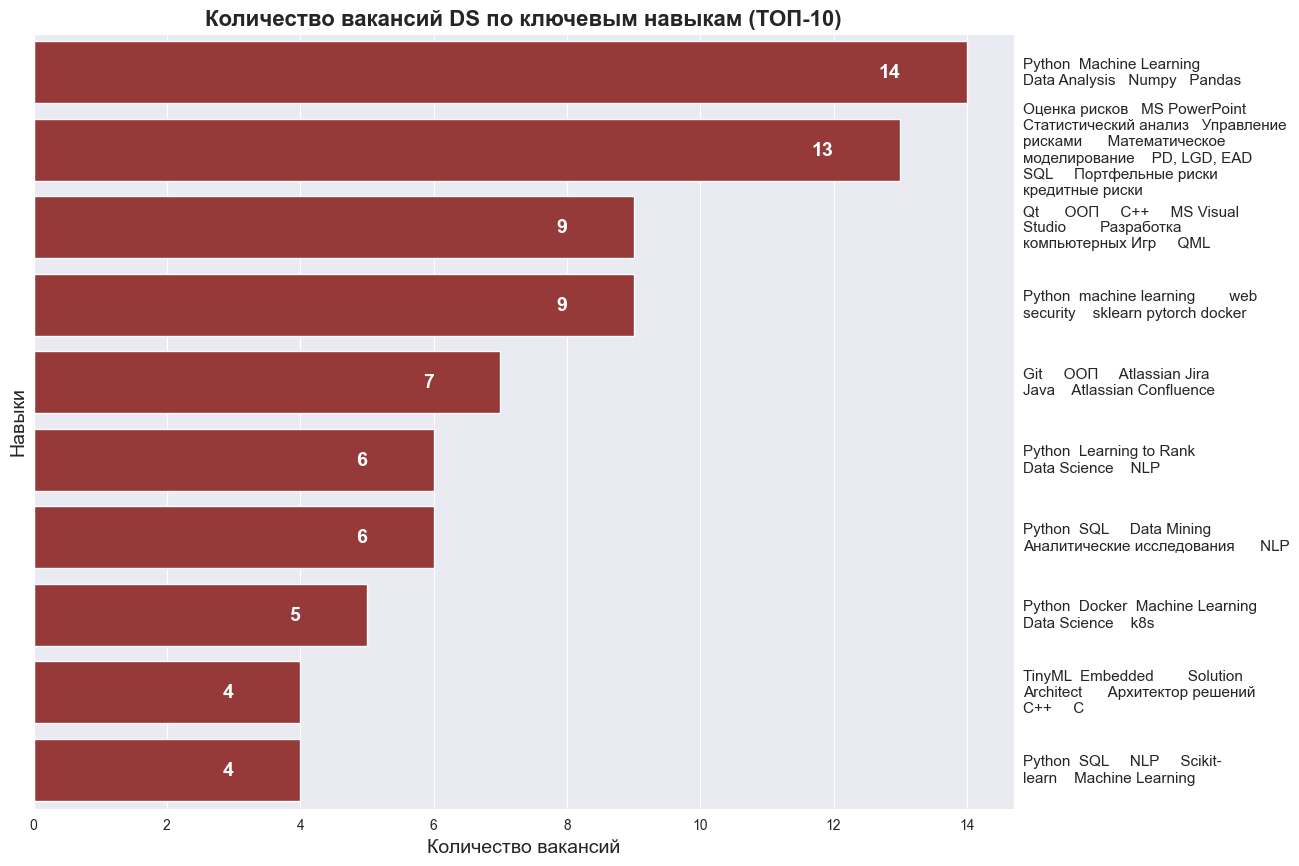

In [751]:
# Запрос для построения диаграммы Тор-10 навыков для DS
query_fin_1 = f'''
            select key_skills, count(id) as cnt
            from vacancies
            where 
            (
                name ilike '%data scientist%' or 
                name ilike '%data science%' or
                name ilike '%исследователь данных%' or
                ((name ilike '%ML%') and (name not ilike '%HTML%')) or
                name ilike '%machine learning%' or
                name ilike '%машинн%обучен%'                
            )  
            and key_skills IS NOT NULL
            and key_skills != ''
            group by key_skills
            order by cnt DESC
            limit 10;
        '''
# результат запроса
df_vac_dt_skills = pd.read_sql_query(query_fin_1, connection)
# Рисуем диаграмму
import textwrap
fig, ax = plt.subplots(figsize=(14, 10))
chart_6_1 = sns.barplot(data=df_vac_dt_skills.head(10), y='key_skills', x='cnt', color='brown', ax=ax)
# Задаем позицию графика [left, bottom, width, height]
ax.set_position([0.00, 0.125, 0.7, 0.775])
# Переносим длинные названия (максимум 35 символов в строке)
wrapped_labels = ['\n'.join(textwrap.wrap(label, width=35)) for label in df_vac_dt_skills['key_skills'].head(10)]
# Подписи навыков справа с переносом
ax.tick_params(axis='y', labelleft=False, labelright=True, labelsize=11)
ax.set_yticklabels(wrapped_labels, fontsize=11, ha='left', va='center')
ax.set_title('Количество вакансий DS по ключевым навыкам (ТОП-10)', fontsize=16, fontweight='bold')
ax.set_xlabel("Количество вакансий", fontsize=14)
ax.set_ylabel("Навыки", fontsize=14)
# Добавляем значения на столбцы
for i, row in df_vac_dt_skills.head(10).iterrows():
    ax.text(row.cnt - 1, i, f'{row.cnt}', va='center', ha='right', fontsize=14, fontweight='bold', color='white')
plt.show()

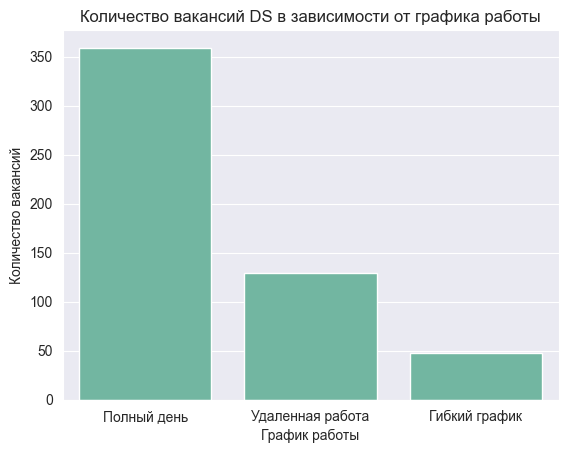

In [752]:
# Запрос для построения диаграммы зависимости количества вакансий от графика работы
query_fin_2 = f'''
            select  schedule, count(id) as cnt
            from vacancies
            where 
            (
                name ilike '%data scientist%' or 
                name ilike '%data science%' or
                name ilike '%исследователь данных%' or
                ((name ilike '%ML%') and (name not ilike '%HTML%')) or
                name ilike '%machine learning%' or
                name ilike '%машинн%обучен%'                
            )  
            group by schedule
            order by cnt desc;
            '''
# результат запроса            
df_vac_dt_sched = pd.read_sql_query(query_fin_2, connection)
# График
chart_6_2 = sns.barplot(df_vac_dt_sched, x='schedule', y='cnt')
chart_6_2.set_title('Количество вакансий DS в зависимости от графика работы')
chart_6_2.set(xlabel="График работы", ylabel="Количество вакансий");

#### Выводы по предметному анализу работодателей
- Вакансии по работе с данными (1771) составляют около 4 %  от общего числа вакансий. Возможно, это связано с тем, что 
  область DS развивается и, в будущем, количество DS-вакансий будет расти.
- Вакансии для начинающего дата-сайентиста (51) составлят около 3 % от общего числа DS-вакансий, что крайне мало.
- От дата-сайентиста в среднем требуется 7 ключевых навыков, что является высоким входным порогом.
- Python - наиболее востребованный ключевой навык в вакансиях дата-сайентиста.
- Опытным дата-сайентистам предлагается достаточно высокий уровень заработной платы (в среднем 243 115 руб.)
- Самым востребованным графиком работы является полный рабочий день.

# Общий вывод по проекту

In [753]:
# подведем итог исследования, обобщите выводы
# здесь можно (это будет плюсом) провести дополнительные исследования данных, сделать прогнозы, продумать варианты продолжения исследования

##### Для формулировки общего вывода построим диаграммы:
- ТОП-10 работодателей по количеству вакансий
- ТОП-10 специализаций по количеству вакансий 

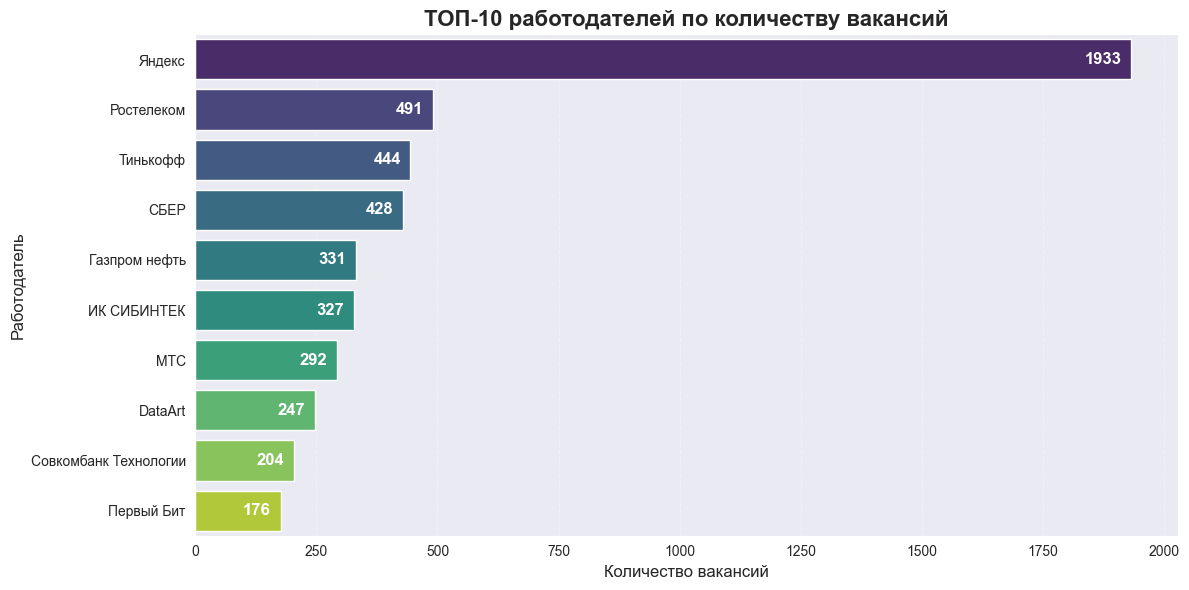

In [754]:
#Анализ количества работодателей
# текст запроса
query_emp_1 = f'''
                select employers.name, count(vacancies.id) as cnt 
                from vacancies
                left join employers on employers.id = vacancies.employer_id 
                group by employers.name
                order by cnt desc
                limit 10;
                ;
            '''
# результат запроса (датафрейм)
df_count_vac_emp = pd.read_sql_query(query_emp_1, connection)
# Строим диаграмму
fig, ax = plt.subplots(figsize=(12, 6))
# Сортируем данные по убыванию для отображения сверху
df_sorted = df_count_vac_emp.sort_values('cnt', ascending=False)
sns.barplot(data=df_sorted, y='name', x='cnt', palette='viridis', ax=ax)
# Настройка заголовков и подписей
ax.set_title('ТОП-10 работодателей по количеству вакансий', fontsize=16, fontweight='bold')
ax.set_xlabel('Количество вакансий', fontsize=12)
ax.set_ylabel('Работодатель', fontsize=12)
# Добавляем значения на столбцы
for i, row in df_sorted.iterrows():
    ax.text(row.cnt - 20, i, f'{row.cnt}', 
            va='center', ha='right', fontsize=12, fontweight='bold', color='white')
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

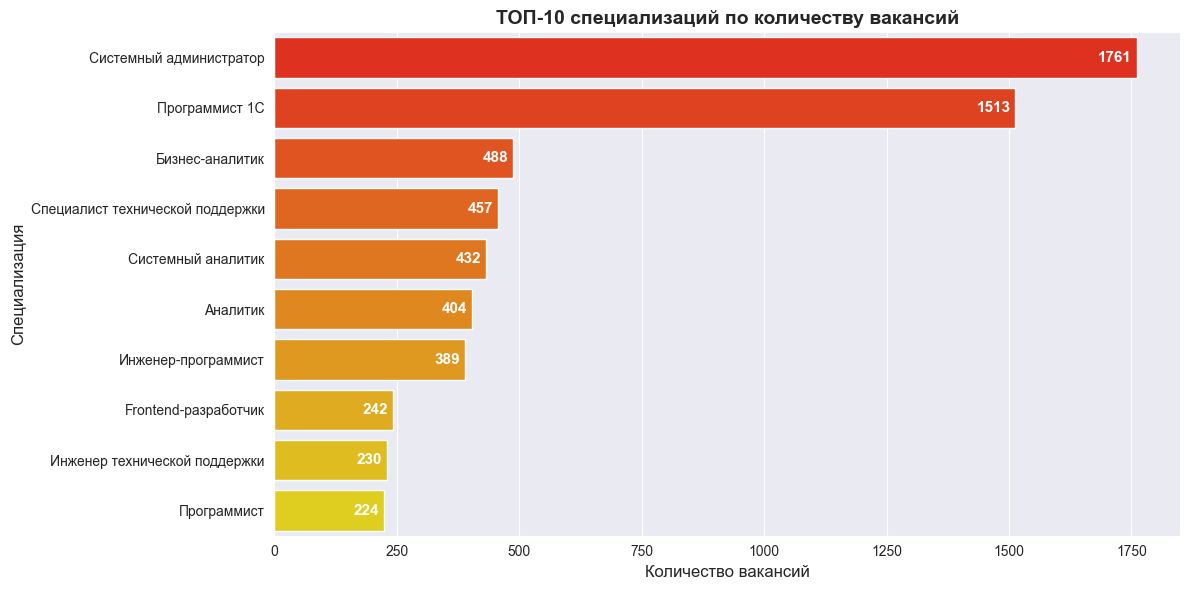

In [755]:
#Анализ количества специализаций
# текст запроса
query_name_2 = f'''
                    select  name, count(*) as cnt
                    from (
                    select 
                        replace( trim(name), 'Программист 1С', 'Программист 1C' ) as name
                    from vacancies
                    ) table_1
                    group by name
                    order by cnt desc
                    limit 10;
                '''
# результат запроса (датафрейм)         
df_vac_top_name = pd.read_sql_query(query_name_2, connection)
# Сортируем данные
df_vac_top_name_sorted = df_vac_top_name.sort_values('cnt', ascending=False)
# Строим диаграмму
plt.figure(figsize=(12, 6))
sns.barplot(data=df_vac_top_name_sorted, y='name', x='cnt', palette='autumn')
plt.ylabel('Специализация', fontsize=12)
plt.xlabel('Количество вакансий', fontsize=12)
plt.title('ТОП-10 специализаций по количеству вакансий', fontsize=14, fontweight='bold')
# Добавляем значения
for i, row in df_vac_top_name_sorted.iterrows():
    plt.text(row.cnt - 10, i, f'{row.cnt}', 
             va='center', ha='right', fontsize=11, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

## Общий вывод по проекту
- Проведен анализ 49197 вакансий с сайта HeadHunter.
- Среди работодателей с большим отрывом (в 4 раза) лидирует Яндекс, разместивший 1933 вакансии в наибольшем количестве регионов (181).
- Наиболее востребованы Системные аналитики (1761 вакансия) и Программисты 1С (1513 вакансий).
- К специализации Data Science относится около 4 % от общего числа вакансий, при этом работодатели предлагают высокую
  заработную плату для опытных соискателей (243 115 руб). Хочется надеяться, что востребованность Data Science со временем будет неуклонно расти.
- Основная часть вакансий предполагает полный рабочий день с полной занятостью в Москве.
- В основной части вакансий указан опыт работы от 1 до 3 лет. 

##### Возможные дальнейшие шаги исследования:
- Распределение вакансий по регионам с учетом требуемых специализаций.
- Анализ привлекательности регионов с учетом условий труда и уровня заработной платы для соискателей с различным опытом работы и специализациями.